In [112]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA, SparsePCA
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers

In [2]:
tf.random.set_seed(0)
np.random.seed(0)

# Preparação dos Dados

## Dados

- Fonte: https://www.kaggle.com/datasets/brynja/wineuci

In [3]:
cols = [
    'class','alcohol','malic_acid','ash','alcalinity_of_ash','magnesium','total_phenols','flavanoids',
    'nonflavanoid_phenols','proanthocyanins','color_intensity','hue','od280_od315','proline'
]
data = pd.read_csv("C:/Users/aless/Downloads/Wine.csv", header=None, names=cols)
data['class'] = data['class'].astype(str)

features = data.iloc[:,1:]
X_scaled = features.sub(features.mean()).div(features.std())
data.shape

(178, 14)

In [4]:
data.head()

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 178 non-null    object 
 1   alcohol               178 non-null    float64
 2   malic_acid            178 non-null    float64
 3   ash                   178 non-null    float64
 4   alcalinity_of_ash     178 non-null    float64
 5   magnesium             178 non-null    int64  
 6   total_phenols         178 non-null    float64
 7   flavanoids            178 non-null    float64
 8   nonflavanoid_phenols  178 non-null    float64
 9   proanthocyanins       178 non-null    float64
 10  color_intensity       178 non-null    float64
 11  hue                   178 non-null    float64
 12  od280_od315           178 non-null    float64
 13  proline               178 non-null    int64  
dtypes: float64(11), int64(2), object(1)
memory usage: 19.6+ KB


In [6]:
data['class'].value_counts(normalize=True).to_frame().join(data['class'].value_counts()).round(2)

,proportion,count
class,,
2,0.40,71
1,0.33,59
3,0.27,48


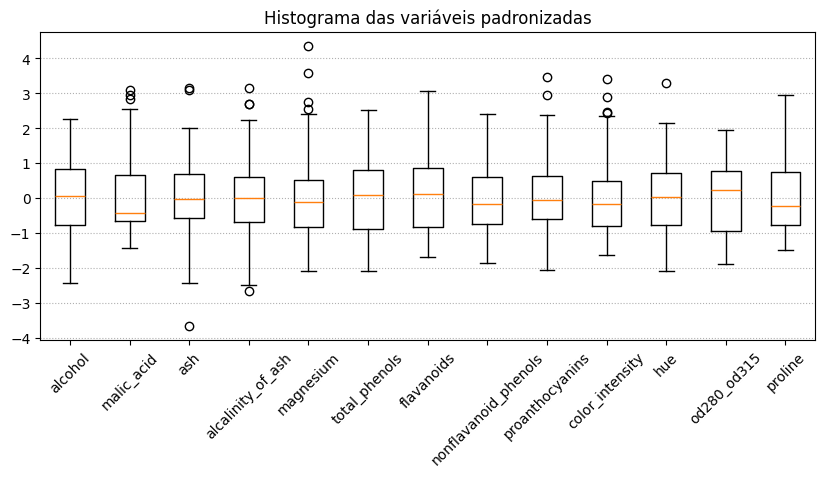

In [7]:
fig, ax = plt.subplots(figsize=(10,4))
ax.boxplot(X_scaled)
ax.set_xticklabels(X_scaled.columns, rotation=45)
ax.grid(axis='y', linestyle=':')
ax.set_title('Histograma das variáveis padronizadas')
plt.show()

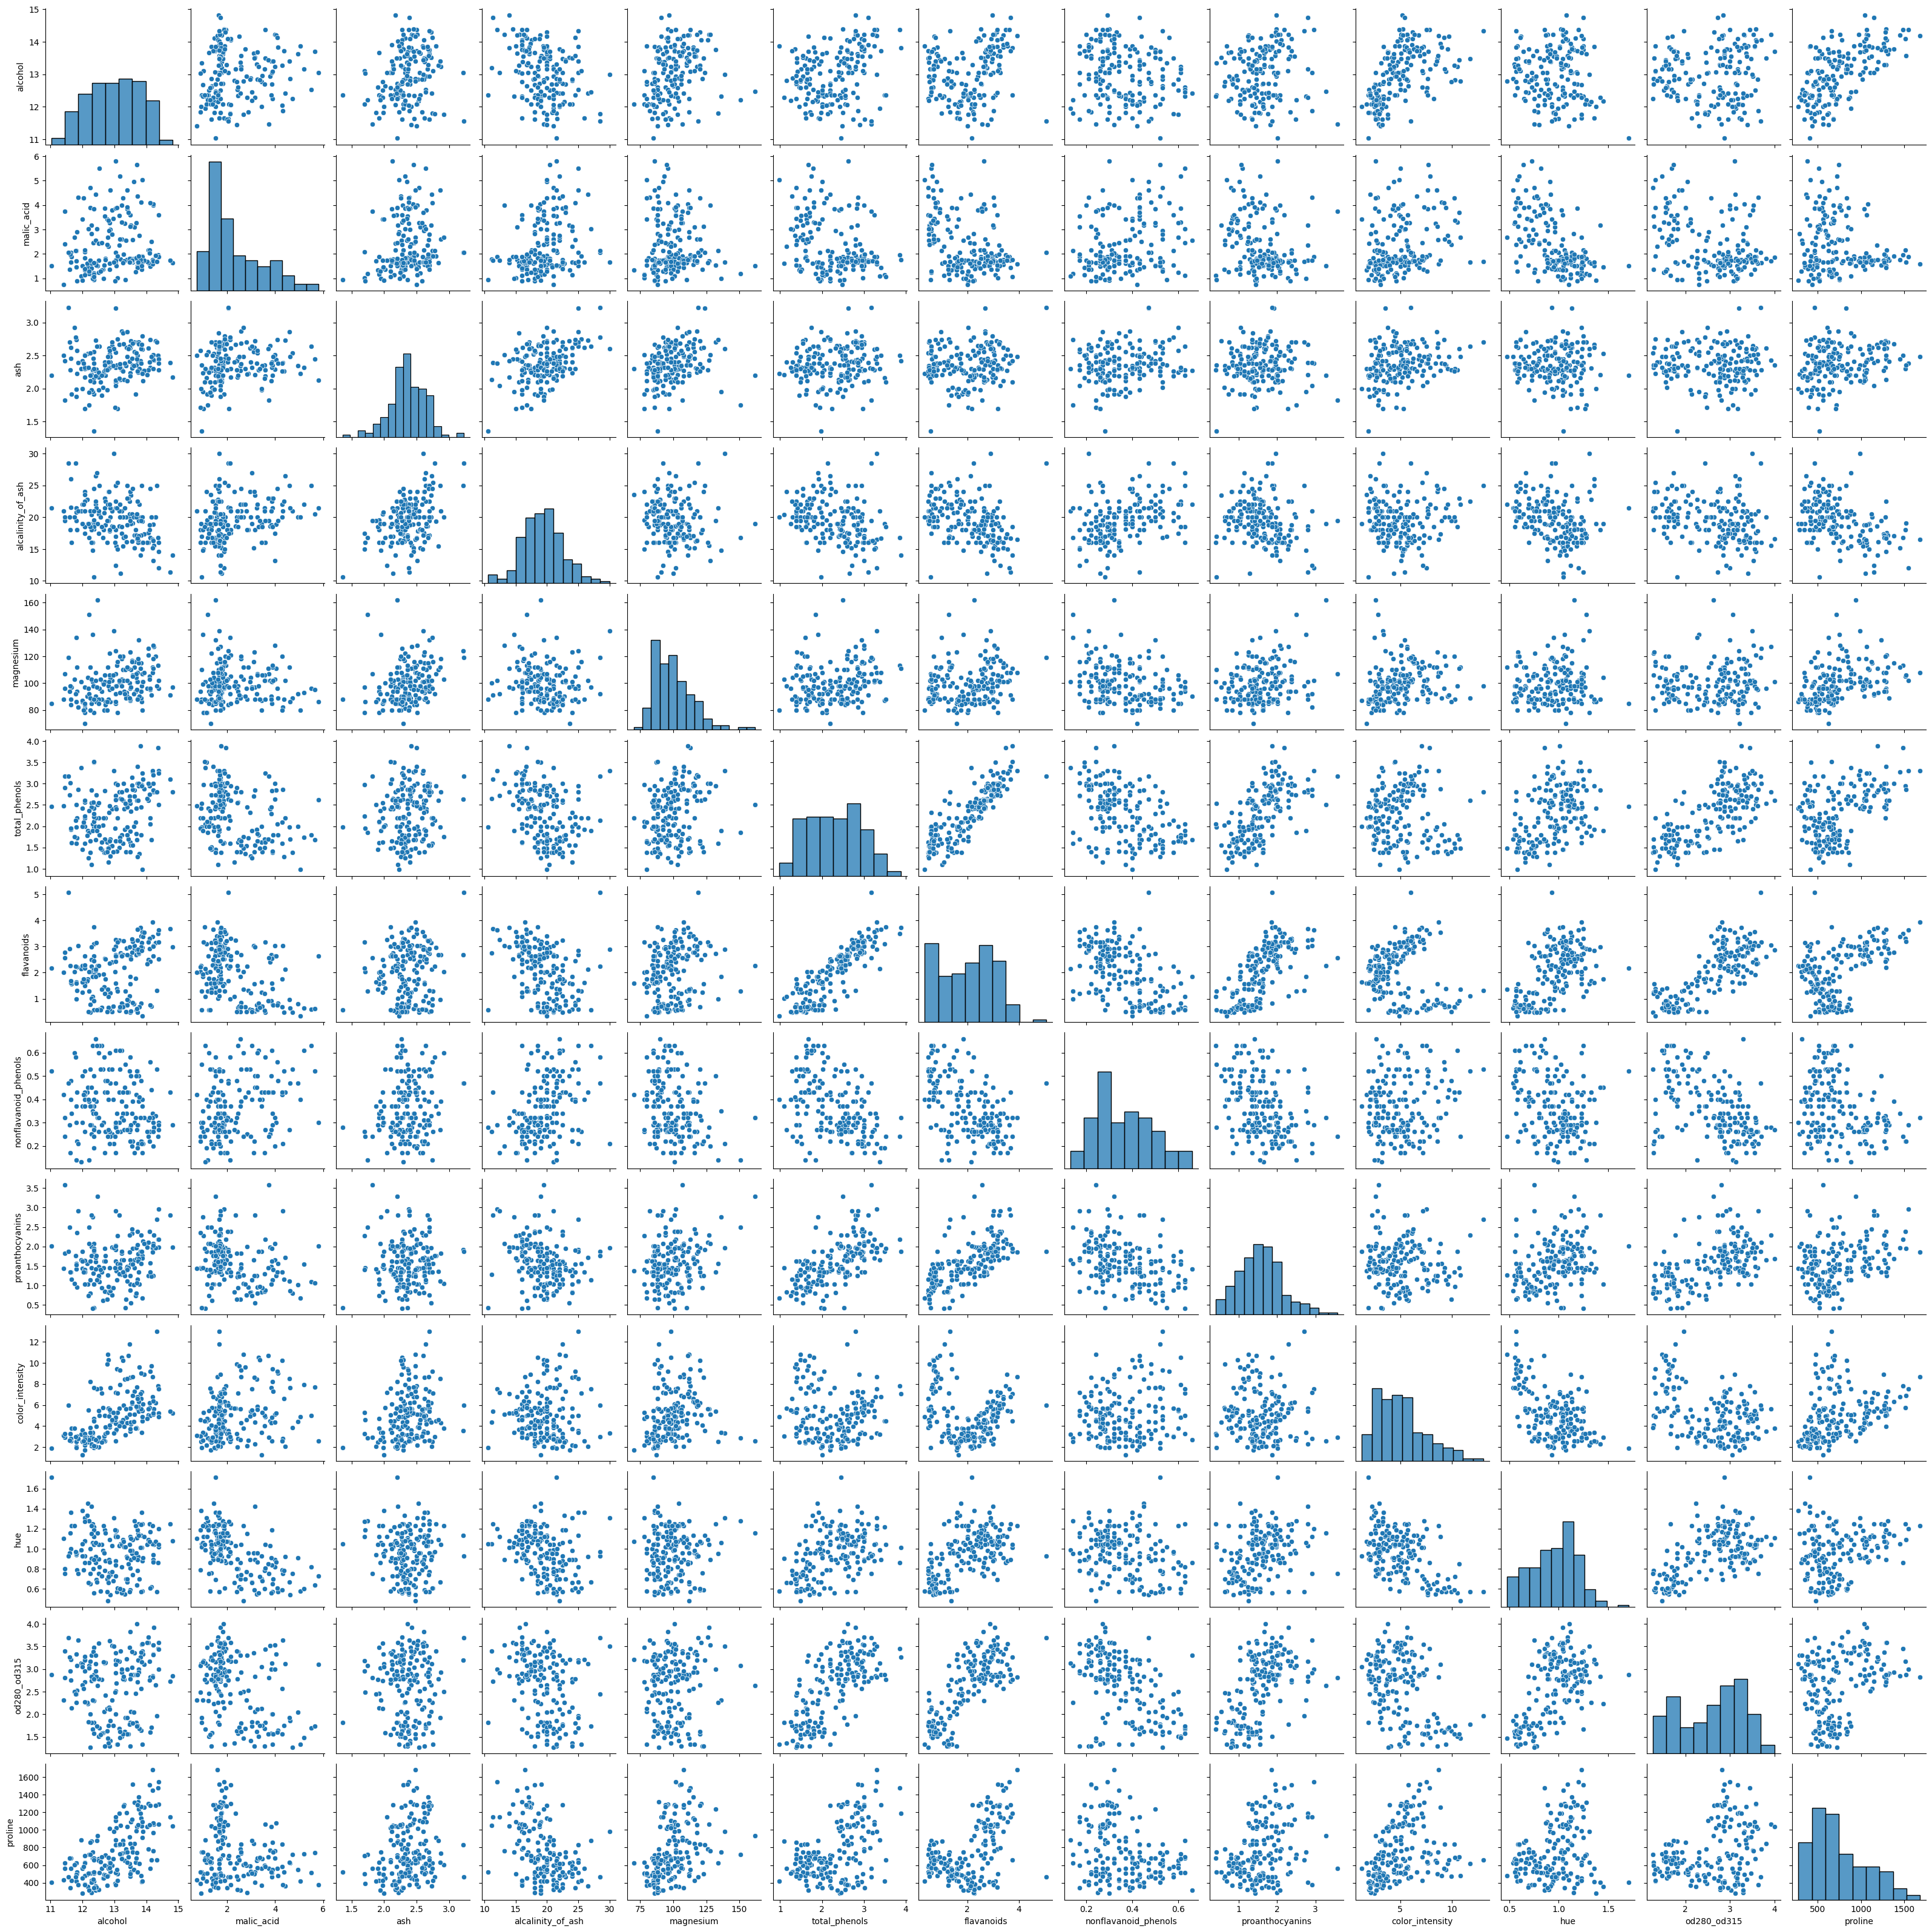

In [149]:
sns.pairplot(data)

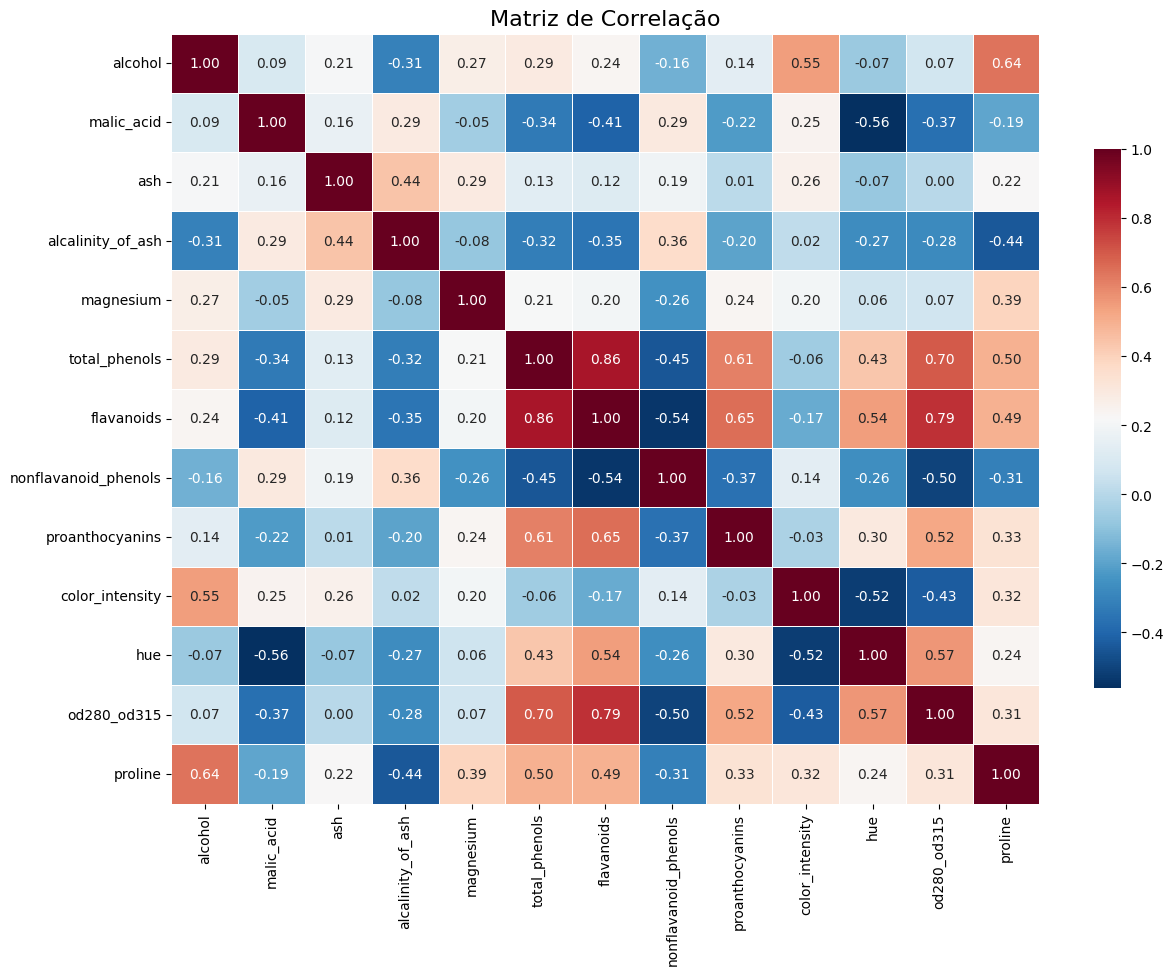

In [9]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    features.corr(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    linewidths=.5,
    cbar_kws={"shrink": .7}
)
plt.title("Matriz de Correlação", fontsize=16)
# plt.savefig("C:/Users/aless/Desktop/Codes/masters/Estatística/Multivariada/img/matriz_correlacao.png", dpi=300, bbox_inches='tight')
plt.show()

## PCA

In [10]:
pca = PCA()
pca.fit(X_scaled)

P = pca.components_.T # matriz nxn cujas colunas são os componentes principais
Lambda = pca.explained_variance_ # matriz nxn cuja diagonal são os autovalores

Y = pca.transform(X_scaled) # scores
explained = pca.explained_variance_ratio_

In [ ]:
# X_scaled@P[:,:2]

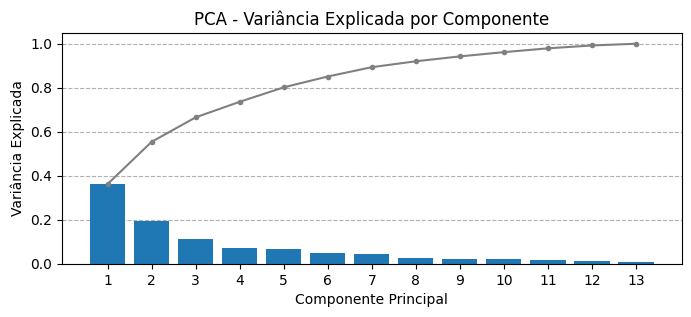

In [11]:
plt.figure(figsize=(8, 3))
plt.bar(range(1, len(explained)+1), explained, zorder=2)
plt.plot(range(1, len(explained)+1), np.cumsum(explained), marker='.', color='gray')

plt.xlabel("Componente Principal")
plt.ylabel("Variância Explicada")
plt.title("PCA - Variância Explicada por Componente")
plt.xticks(range(1, len(explained)+1))
plt.grid(linestyle='--', zorder=0, axis='y')
plt.show()

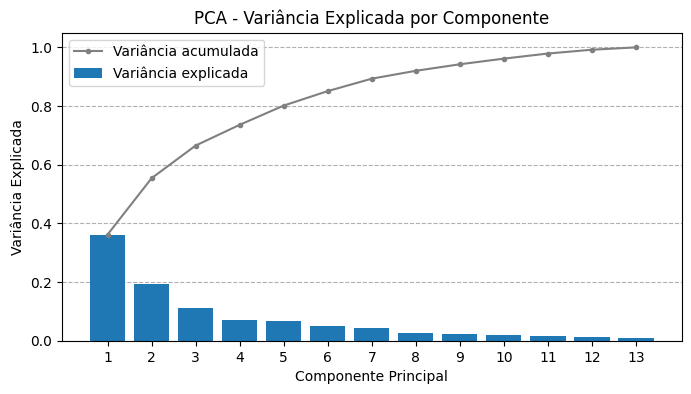

In [12]:
plt.figure(figsize=(8, 4))

plt.bar(
    range(1, len(explained)+1),
    explained,
    zorder=2,
    label="Variância explicada"
)

plt.plot(
    range(1, len(explained)+1),
    np.cumsum(explained),
    marker='.',
    color='gray',
    label="Variância acumulada"
)

plt.xlabel("Componente Principal")
plt.ylabel("Variância Explicada")
plt.title("PCA - Variância Explicada por Componente")
plt.xticks(range(1, len(explained)+1))
plt.grid(linestyle='--', zorder=0, axis='y')

plt.legend()   # ← legenda aqui

plt.show()


In [13]:
n_components=2
pca2 = PCA(n_components)
X_pca2 = pca2.fit_transform(X_scaled)

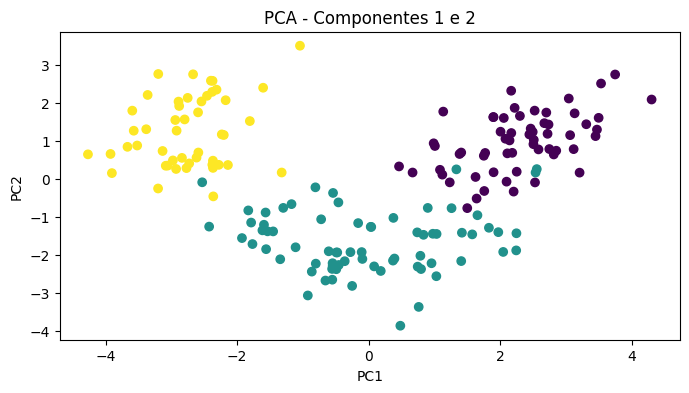

In [14]:
plt.figure(figsize=(8,4))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=data['class'].astype(int))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Componentes 1 e 2")
plt.show()

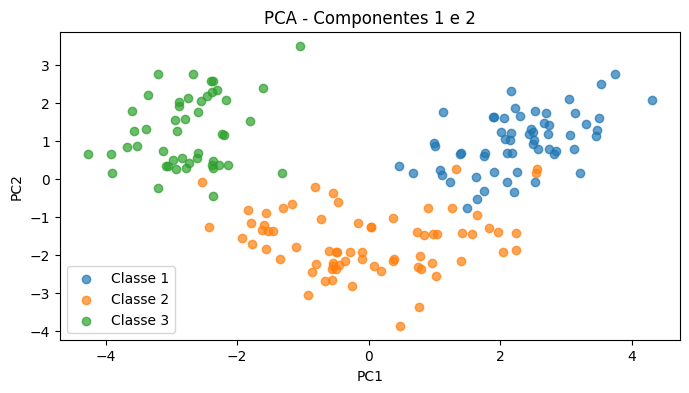

In [15]:
plt.figure(figsize=(8,4))

classes = data['class'].unique()

for cls in classes:
    mask = data['class'] == cls
    plt.scatter(
        X_pca2[mask, 0],
        X_pca2[mask, 1],
        label=f"Classe {cls}",
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Componentes 1 e 2")
plt.legend()
plt.show()

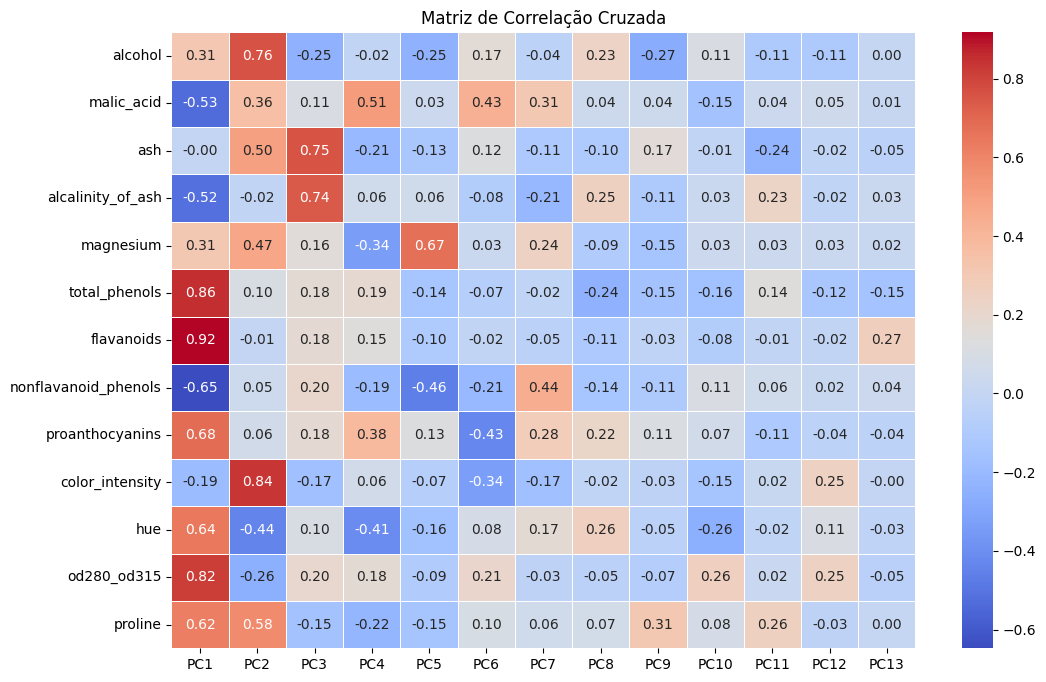

In [16]:
loadings = P * np.sqrt(Lambda)
loading_df = pd.DataFrame(
    loadings,
    index=features.columns,
    columns=[f"PC{i+1}" for i in range(loadings.shape[1])]
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    loading_df,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=.5
)
plt.title("Matriz de Correlação Cruzada")
plt.show()

## Dados com posto incompleto

In [21]:
np.linalg.matrix_rank(features)

np.int64(13)

In [22]:
#Y[:,:n_components]@P[:,:n_components].T
X_singular = pca2.inverse_transform(X_pca2) 
X_singular_scaled = (X_singular-np.mean(X_singular)) / np.std(X_singular)
np.linalg.matrix_rank(X_singular)

np.int64(2)

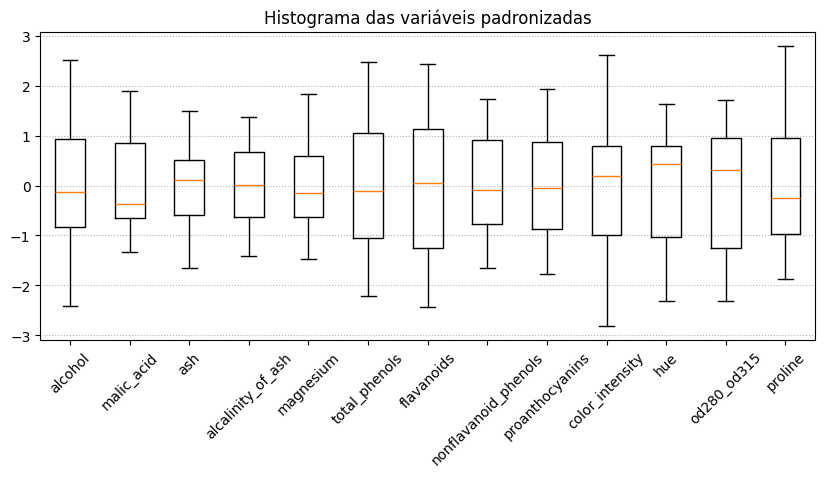

In [23]:
fig, ax = plt.subplots(figsize=(10,4))
ax.boxplot(X_singular_scaled)
ax.set_xticklabels(X_scaled.columns, rotation=45)
ax.grid(axis='y', linestyle=':')
ax.set_title('Histograma das variáveis padronizadas')
plt.show()

# Modelos

## PCA Esparso

In [24]:
spca = SparsePCA(alpha=15, random_state=0)
spca.fit(X_singular_scaled)

P_spca = spca.components_.T # matriz de componentes esparsas
Y_spca = spca.transform(X_singular_scaled) # scores

In [25]:
pd.DataFrame(spca.components_, columns=features.columns).abs().sum().where(lambda x: x > 0).dropna()

total_phenols      1.0
flavanoids         1.0
color_intensity    1.0
od280_od315        1.0
proline            1.0
dtype: float64

In [26]:
df = pd.DataFrame(spca.components_, columns=features.columns)

def highlight_ones(val):
    if val == 1:
        return "background-color: lightgreen; font-weight: bold;"
    return ""

def zebra_rows(row):
    # Aplica cor apenas na linha inteira
    if row.name % 2 == 0:   # linhas pares
        return ["background-color: #ffffff"] * len(row)
    else:                    # linhas ímpares
        return ["background-color: #f7f7f7"] * len(row)

(df.style
    .apply(zebra_rows, axis=1)            # alternância de linhas
    .map(highlight_ones)             # destaque do valor 1
    .format("{:.0f}")                     # zero casas decimais
)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,1
3,-0,-0,-0,-0,-0,1,-0,-0,-0,-0,-0,-0,-0
4,0,0,0,0,0,0,0,0,0,0,0,1,0
5,0,0,0,0,0,0,0,0,0,1,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0


In [64]:
spca = SparsePCA(n_components=2, alpha=15, random_state=0)
spca.fit(X_singular_scaled)
Y2_spca = spca.transform(X_singular_scaled) # scores
X_recon_spca = spca.inverse_transform(Y2_spca)

In [65]:
np.mean((X_singular_scaled - X_recon_spca)**2)

np.float64(0.7281065199779564)

In [30]:
pd.DataFrame(spca.components_, columns=features.columns).round(2).T

,0,1
alcohol,0.00,0.0
malic_acid,0.00,0.0
ash,0.00,0.0
alcalinity_of_ash,0.00,0.0
magnesium,0.00,0.0
total_phenols,0.25,0.0
flavanoids,0.97,0.0
nonflavanoid_phenols,0.00,0.0
proanthocyanins,0.00,0.0
color_intensity,0.00,1.0


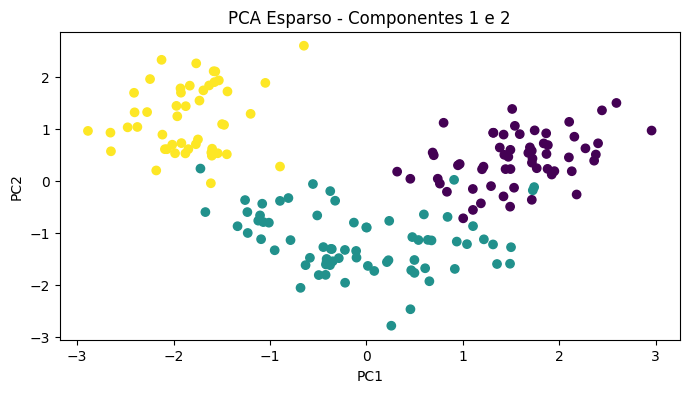

In [31]:
plt.figure(figsize=(8,4))
plt.scatter(Y2_spca[:,0], Y2_spca[:,1], c=data['class'].astype(int))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Esparso - Componentes 1 e 2")
plt.show()

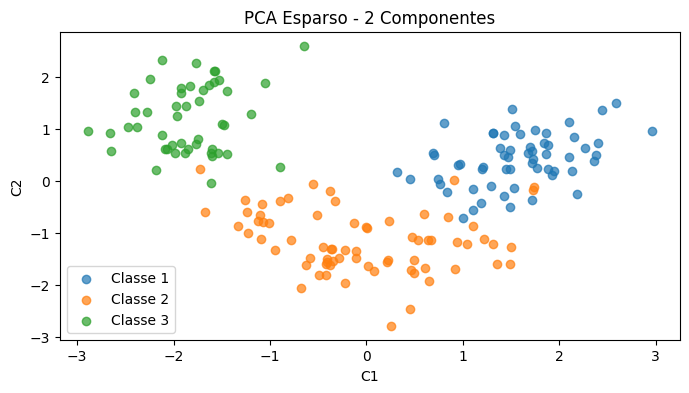

In [32]:
plt.figure(figsize=(8,4))

classes = data['class'].unique()

for cls in classes:
    mask = data['class'] == cls
    plt.scatter(
        Y2_spca[mask, 0],
        Y2_spca[mask, 1],
        label=f"Classe {cls}",
        alpha=0.7
    )

plt.xlabel("C1")
plt.ylabel("C2")
plt.title("PCA Esparso - 2 Componentes")
plt.legend()
plt.show()


## Autoencoder linear

In [147]:
latent_dim = 10
alpha = 0.07

inp = layers.Input(shape=(X_singular_scaled.shape[1],))
encoded = layers.Dense(latent_dim, activation='linear', use_bias=False, 
                       name='enc', kernel_regularizer=regularizers.l1(alpha))(inp)
decoded = layers.Dense(X_singular_scaled.shape[1], activation='linear', use_bias=False, 
                       name='dec', kernel_regularizer=regularizers.l1(alpha))(encoded)

ae_linear = models.Model(inputs=inp, outputs=decoded)
ae_linear.compile(optimizer=optimizers.Adam(learning_rate=1e-2), loss='mse')
ae_linear.summary()

history = ae_linear.fit(X_singular_scaled, X_singular_scaled, epochs=200, batch_size=32, verbose=0)

encoder_linear = models.Model(inputs=inp, outputs=ae_linear.get_layer('enc').output)
Z = encoder_linear.predict(X_singular_scaled)
X_recon = ae_linear.predict(X_singular_scaled)

encoder_weights = ae_linear.get_layer('enc').get_weights()[0]
decoder_weights = ae_linear.get_layer('dec').get_weights()[0]

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)          │ (None, 13)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc (Dense)                          │ (None, 10)                  │             130 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec (Dense)                          │ (None, 13)                  │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 260 (1.02 KB)

 Trainable params: 260 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [137]:
pd.DataFrame(encoder_weights).round(2).abs().sum()

0    0.00
1    0.00
2    0.00
3    0.00
4    0.00
5    0.00
6    1.88
7    0.00
8    0.00
9    2.49
dtype: float32

In [140]:
pd.DataFrame(encoder_weights@decoder_weights).round(2)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.17,0.06,0.10,0.00,0.09,0.00,-0.00,0.00,0.00,0.20,-0.08,-0.03,0.12
1,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00
2,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,0.00
3,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00
4,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,0.00
5,0.00,-0.00,0.00,-0.00,0.00,0.01,0.01,-0.01,0.01,-0.00,0.01,0.01,0.01
6,0.27,-0.44,0.01,-0.44,0.24,0.81,0.87,-0.57,0.61,-0.02,0.55,0.75,0.59
7,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00
8,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00
9,0.55,0.18,0.31,0.00,0.28,0.00,-0.00,0.00,0.00,0.63,-0.26,-0.09,0.38


In [146]:
np.linalg.matrix_rank((encoder_weights@decoder_weights).round(2))

np.int64(13)

In [115]:
np.linalg.matrix_rank(Z)

np.int64(2)

In [52]:
np.linalg.matrix_rank(X_recon)

np.int64(2)

In [148]:
np.mean((X_singular_scaled - X_recon)**2)

np.float64(0.05100869206179862)

In [42]:
np.mean((X_singular_scaled - X_recon)**2)

np.float64(8.544663935260721e-15)

In [90]:
corr = np.corrcoef(Y[:,:n_components].T, Z.T)   # shape (2k,2k)
k = n_components
corr_cross = corr[:k, k:2*k]     # top-right block: corr(Zp[:,i], Za[:,j])
df_corr = pd.DataFrame(corr_cross, index=[f"PC{i+1}" for i in range(k)], columns=[f"AE{i+1}" for i in range(k)]).round(2)

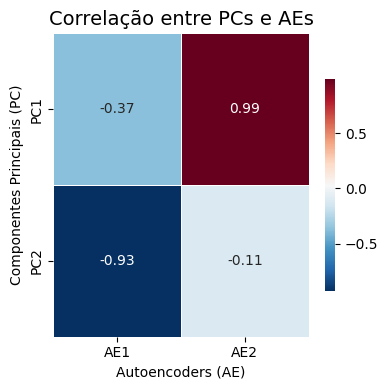

In [76]:
plt.figure(figsize=(4, 4))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap="RdBu_r", linewidths=.5, cbar_kws={"shrink": .7})

plt.title("Correlação entre PCs e AEs", fontsize=14)
plt.xlabel("Autoencoders (AE)")
plt.ylabel("Componentes Principais (PC)")
plt.tight_layout()
plt.show()

In [48]:
np.mean((X_scaled - X_recon)**2)

np.float64(0.5098609980815573)

In [47]:
np.mean((X_scaled - X_singular)**2)

np.float64(0.4434313545405875)

## Factor Analysis